# Time after transplantation

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.multitest import multipletests

ROOT = next(
    folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (folder / "result_summary" / "data_helper.py").exists()
)
sys.path[:0] = [
    str(ROOT / "result_summary"),
    str(ROOT / "result_summary" / "differential_rules"),
]

import data_helper as dh
import differential_stats as ds
import differential_vis as dv

warnings.filterwarnings("ignore")

ORGANS = ["Colon", "Duodenum"]
TIME_GROUPS = ["<30", "30-100", ">100"]
DISPLAY_GROUPS = ["Control", *TIME_GROUPS]
MIN_CELLS = 20
MIN_BIOPSIES = 3
MIN_RULE_BIOPSIES = 3
N_PERMUTATIONS = 5_000
FDR_CUTOFF = 0.05
TOP_RULES = 6
TOP_FOV_RULES = 3
METRIC = "Lift"

TEX_TIME_EXPORTS = {
    ("Colon", "CD8T -> Goblet"): "tex_new_time_colon_cd8_goblet.pdf",
    ("Colon", "SMV -> Endothelial"): "tex_new_time_colon_smv_endothelial.pdf",
    ("Colon", "SMV -> Goblet"): "tex_new_time_colon_smv_goblet.pdf",
}
TEX_TIME_FOV_EXPORTS = {
    ("Colon", "CD8T -> Goblet"): "tex_new_time_colon_cd8_goblet_fovs.pdf",
    ("Colon", "SMV -> Endothelial"): "tex_new_time_colon_smv_endothelial_fovs.pdf",
    ("Colon", "SMV -> Goblet"): "tex_new_time_colon_smv_goblet_fovs.pdf",
    ("Duodenum", "Plasma_CD38 -> Fibroblast"): "tex_new_time_duodenum_plasma_cd38_fibroblast_fovs.pdf",
}

POOLED_CONTRASTS = {
    "before_100_vs_after": {
        "title": "<30 + 30–100 days  vs  >100 days",
        "a_name": "≤100 days", "b_name": ">100 days",
        "a_groups": ["<30", "30-100"], "b_groups": [">100"],
    },
    "before_30_vs_after": {
        "title": "<30 days  vs  30–100 + >100 days",
        "a_name": "<30 days", "b_name": "≥30 days",
        "a_groups": ["<30"], "b_groups": ["30-100", ">100"],
    },
}

## Data

In [2]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(rule_max_items=2, kind=None)
rules = dh.prepare_rules(df_results)
_, eligibility, eligible_states = ds.state_tables(
    rules, df_cells, df_fovs["FOV"], MIN_CELLS
)

days = df_biopsy.set_index("Biopsy_ID")["Days after Transplant"]
df_fovs["Days after Transplant"] = df_fovs["Biopsy"].map(days)
biopsy_metadata = (
    df_fovs[["Biopsy", "Organ", "Days after Transplant", "Days after Transplant grouped"]]
    .drop_duplicates(["Biopsy", "Organ"])
    .rename(columns={"Days after Transplant grouped": "Time group"})
)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9647 rules naming no Unidentified.
Kept 9647 rules (max_items=2, kind=None).


In [3]:
def by_biopsy(states, organ):
    """Average eligible FOV states so each biopsy contributes one value."""
    metadata = df_fovs[df_fovs["Organ"] == organ]
    return pd.DataFrame({
        biopsy: states[rows["FOV"]].mean(axis=1)
        for biopsy, rows in metadata.groupby("Biopsy")
    })

In [4]:
def permutation_pvalues(values, labels, observed, seed=0):
    """Largest difference between the three time-window means."""
    rng = np.random.default_rng(seed)
    extreme = np.zeros(len(observed), int)
    valid_count = np.zeros(len(observed), int)
    for _ in range(N_PERMUTATIONS):
        shuffled = rng.permutation(labels)
        means = np.column_stack([
            np.nanmean(values[:, shuffled == group], axis=1)
            for group in TIME_GROUPS
        ])
        null = np.nanmax(means, axis=1) - np.nanmin(means, axis=1)
        valid = np.isfinite(null)
        valid_count += valid
        extreme += valid & (null >= observed - 1e-12)
    return (extreme + 1) / (valid_count + 1)

In [5]:
def analyze_time(organ, values):
    """Biopsy-level temporal screen with one FDR correction across all rules."""
    metadata = biopsy_metadata[
        (biopsy_metadata["Organ"] == organ)
        & biopsy_metadata["Time group"].isin(TIME_GROUPS)
    ]
    biopsies = metadata["Biopsy"].tolist()
    labels = metadata["Time group"].to_numpy()
    matrix = values.reindex(columns=biopsies).to_numpy(float)

    eligible_n = {
        group: np.isfinite(matrix[:, labels == group]).sum(axis=1)
        for group in TIME_GROUPS
    }
    keep = np.sum(np.isfinite(matrix) & (matrix != 0), axis=1) >= MIN_RULE_BIOPSIES
    for count in eligible_n.values():
        keep &= count >= MIN_BIOPSIES

    matrix = matrix[keep]
    names = values.index[keep]
    means = np.column_stack([
        np.nanmean(matrix[:, labels == group], axis=1)
        for group in TIME_GROUPS
    ])
    gap = np.nanmax(means, axis=1) - np.nanmin(means, axis=1)
    p_value = permutation_pvalues(matrix, labels, gap)

    result = pd.DataFrame(index=names)
    for i, group in enumerate(TIME_GROUPS):
        result[f"net_{group}"] = means[:, i]
        result[f"n_eligible_{group}"] = eligible_n[group][keep]
    result["range"] = gap
    result["lowest"] = np.array(TIME_GROUPS)[np.nanargmin(means, axis=1)]
    result["highest"] = np.array(TIME_GROUPS)[np.nanargmax(means, axis=1)]
    result["p_value"] = p_value
    result["fdr"] = multipletests(p_value, method="fdr_bh")[1]
    return result.sort_values(["fdr", "range"], ascending=[True, False])

In [6]:
def strongest(result):
    passed = result[result["fdr"] <= FDR_CUTOFF]
    return (passed if len(passed) else result).head(TOP_RULES).index.tolist()

In [7]:
def result_table(result, rows=12):
    table = result[[
        "net_<30", "net_30-100", "net_>100", "range",
        "lowest", "highest", "fdr",
    ]].head(rows).copy()
    for column in ["net_<30", "net_30-100", "net_>100", "range"]:
        table[column] = (100 * table[column]).round(1)
    return table.rename(columns={
        "net_<30": "<30 net %", "net_30-100": "30–100 net %",
        "net_>100": ">100 net %", "range": "largest gap (pp)",
        "fdr": "temporal FDR",
    })

In [8]:
def analyze_contrast(organ, values, spec):
    metadata = biopsy_metadata[
        (biopsy_metadata["Organ"] == organ)
        & biopsy_metadata["Time group"].isin(TIME_GROUPS)
    ]
    a = metadata.loc[metadata["Time group"].isin(spec["a_groups"]), "Biopsy"].tolist()
    b = metadata.loc[metadata["Time group"].isin(spec["b_groups"]), "Biopsy"].tolist()
    return ds.compare(
        values, a, b, "a", "b",
        min_eligible=MIN_BIOPSIES,
        min_present=MIN_RULE_BIOPSIES,
        n_permutations=N_PERMUTATIONS,
    )

In [9]:
def analyze_pooled_contrasts(organ, values):
    """Apply one FDR correction across both pooled contrasts and all their rules."""
    results = {
        name: analyze_contrast(organ, values, spec)
        for name, spec in POOLED_CONTRASTS.items()
    }
    all_p = pd.concat(
        {name: result["p_value"] for name, result in results.items()},
        names=["contrast", "rule"],
    )
    corrected = pd.Series(
        multipletests(all_p, method="fdr_bh")[1], index=all_p.index
    )
    for name, result in results.items():
        result["fdr"] = corrected.xs(name).reindex(result.index)
        results[name] = result.sort_values(
            ["fdr", "effect_size"],
            key=lambda s: s.abs() if s.name == "effect_size" else s,
            ascending=[True, False],
        )
    return results

In [10]:
def pooled_table(results, rows=8):
    """Compact result table for both pooled contrasts."""
    tables = []
    for name, result in results.items():
        table = result.head(rows).copy()
        table.insert(0, "contrast", POOLED_CONTRASTS[name]["title"])
        table.insert(1, "rule", table.index)
        tables.append(table)
    table = pd.concat(tables, ignore_index=True)
    for column in ["net_a", "net_b", "effect_size"]:
        table[column] = (100 * table[column]).round(1)
    return table[[
        "contrast", "rule", "net_a", "net_b", "effect_size",
        "n_eligible_a", "n_eligible_b", "fdr",
    ]].rename(columns={
        "net_a": "first group net %",
        "net_b": "second group net %",
        "effect_size": "gap (pp)",
        "fdr": "joint FDR",
    })

In [11]:
def representative_time_fovs(rule, organ):
    """Typical rule-bearing biopsy, then a median-metric occurrence inside it."""
    metadata = df_fovs.set_index("FOV")
    allowed = eligibility.columns[eligibility.loc[rule]]
    rows = rules[
        (rules["Clean_Rule"] == rule) & rules["FOV"].isin(allowed)
    ].copy()
    rows["Biopsy"] = rows["FOV"].map(metadata["Biopsy"])
    rows["stage"] = rows["FOV"].map(metadata["Days after Transplant grouped"])
    rows = rows[rows["FOV"].map(metadata["Organ"]) == organ]

    examples = []
    for group in DISPLAY_GROUPS:
        biopsies = biopsy_metadata.loc[
            (biopsy_metadata["Organ"] == organ)
            & (biopsy_metadata["Time group"] == group), "Biopsy"
        ]
        scores = biopsy_values[organ].reindex(columns=biopsies).loc[rule].dropna()
        current = rows[
            (rows["stage"] == group) & rows["Biopsy"].isin(scores.index)
        ]
        available = scores.reindex(current["Biopsy"].unique()).dropna()
        if available.empty:
            continue
        biopsy = (available - scores.mean()).abs().idxmin()
        current = current[current["Biopsy"] == biopsy]
        state = current["state"].value_counts().idxmax()
        candidates = current[current["state"] == state]
        values = pd.to_numeric(candidates[METRIC], errors="coerce")
        index = ((values - values.median()).abs().idxmin()
                 if values.notna().any() else candidates.index[0])
        row = candidates.loc[index]
        examples.append({
            "rule": rule, "stage": group, "Biopsy": biopsy,
            "FOV": row["FOV"], "state": row["state"],
            "metric": row[METRIC], "biopsy_net": scores[biopsy],
            "fdr": row.get("Individual_FDR", np.nan),
            "antecedent_cells": dh.base_items(row["Antecedents"]),
            "consequent_cells": dh.base_items(row["Consequents"]),
        })
    return pd.DataFrame(examples)

In [12]:
def show_time_fovs(organ):
    chosen = strongest(time_results[organ])[:TOP_FOV_RULES]
    chosen += [rule for saved_organ, rule in TEX_TIME_FOV_EXPORTS
               if saved_organ == organ]
    for rule in dict.fromkeys(chosen):
        examples = representative_time_fovs(rule, organ)
        dv.plot_pair_rule_fovs(
            examples, DISPLAY_GROUPS, df_cells, df_fovs, organ,
            "Post-transplant window", metric=METRIC, min_cells=MIN_CELLS,
            selection=f"biopsy nearest group mean; median-{METRIC.lower()} occurrence inside it",
            save=TEX_TIME_FOV_EXPORTS.get((organ, rule)),
        )

In [13]:
biopsy_values = {organ: by_biopsy(eligible_states, organ) for organ in ORGANS}
time_results = {organ: analyze_time(organ, biopsy_values[organ]) for organ in ORGANS}
pooled_results = {
    organ: analyze_pooled_contrasts(organ, biopsy_values[organ])
    for organ in ORGANS
}

display(
    biopsy_metadata.groupby(["Organ", "Time group"], observed=False)
    .size().unstack(fill_value=0).reindex(columns=DISPLAY_GROUPS, fill_value=0)
)
for organ in ORGANS:
    passed = int((time_results[organ]["fdr"] <= FDR_CUTOFF).sum())
    pooled_passed = sum(
        int((result["fdr"] <= FDR_CUTOFF).sum())
        for result in pooled_results[organ].values()
    )
    print(f"{organ}: {passed} temporal and {pooled_passed} pooled results pass FDR {FDR_CUTOFF}")

Time group,Control,<30,30-100,>100
Organ,,,,
Colon,4,5,8,6
Duodenum,10,23,6,11


Colon: 0 temporal and 0 pooled results pass FDR 0.05
Duodenum: 0 temporal and 0 pooled results pass FDR 0.05


## Biopsy coverage

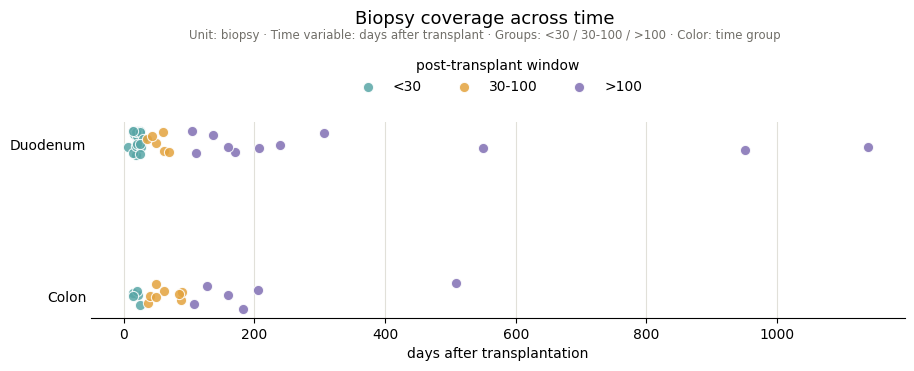

In [14]:
dv.plot_time_coverage(
    biopsy_metadata,
    day_col="Days after Transplant",
    group_col="Time group",
    groups=TIME_GROUPS,
)


## Full temporal screen

### Colon

,<30 net %,30–100 net %,>100 net %,largest gap (pp),lowest,highest,temporal FDR
Clean_Rule,,,,,,,
CD8T -> Goblet,-6.7,-31.6,-75.0,68.3,>100,<30,0.334933
SMV -> Endothelial,100.0,83.3,25.0,75.0,>100,<30,0.361728
SMV -> Goblet,-15.0,-51.3,-68.3,53.3,>100,<30,0.361728
Muscle -> SMV,41.7,-33.3,-66.7,108.3,>100,<30,0.530869
Goblet -> Muscle,-100.0,-30.6,-58.3,69.4,<30,30-100,0.530869
Endothelial -> CD8T,0.0,10.0,66.7,66.7,<30,>100,0.530869
Macrophage -> CD4T,40.0,19.0,0.0,40.0,>100,<30,0.530869
CD8T -> Epithelial,6.7,-3.1,-25.0,31.7,>100,<30,0.530869
Muscle -> Goblet,-91.7,-34.7,-87.5,56.9,<30,30-100,0.587994


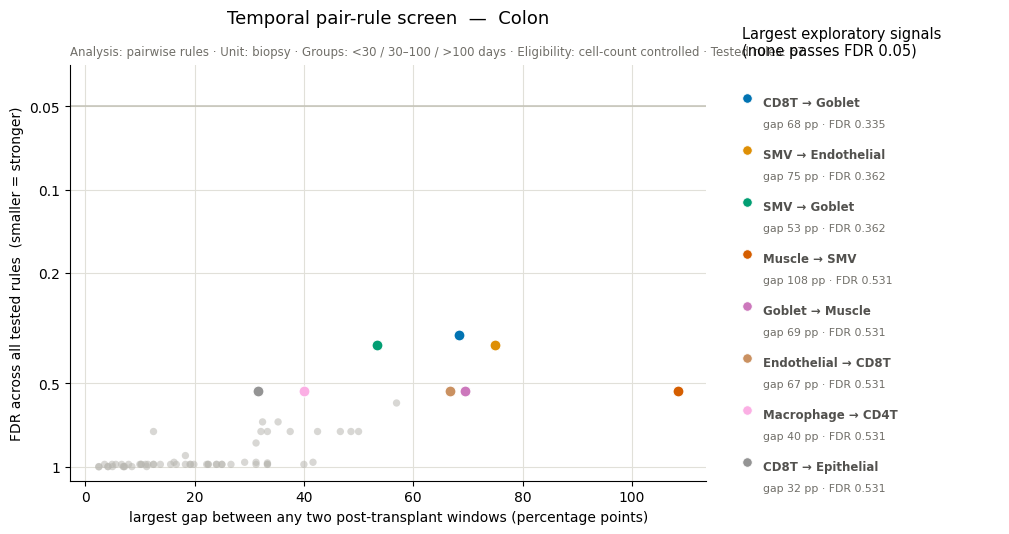

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_cd8_goblet.pdf


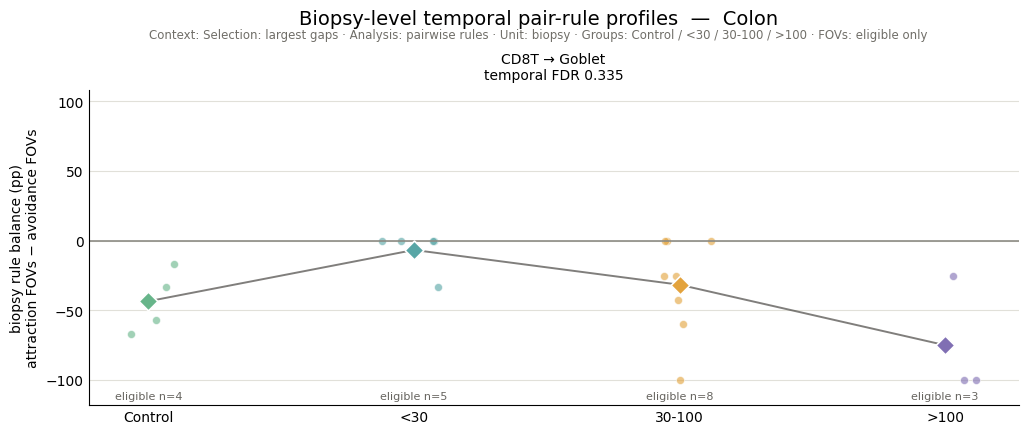

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_smv_endothelial.pdf


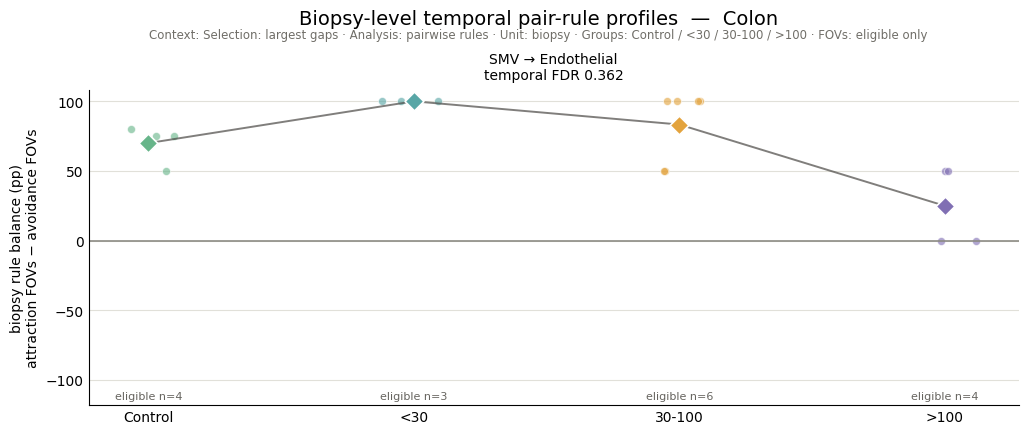

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_smv_goblet.pdf


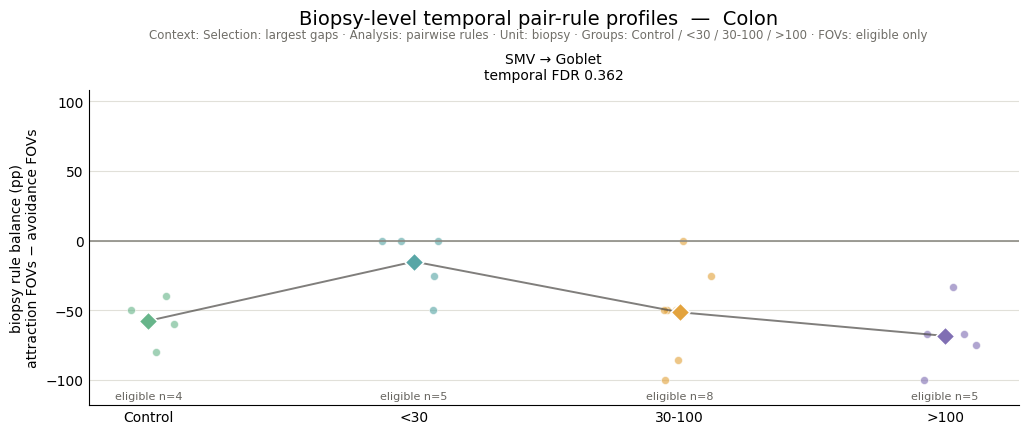

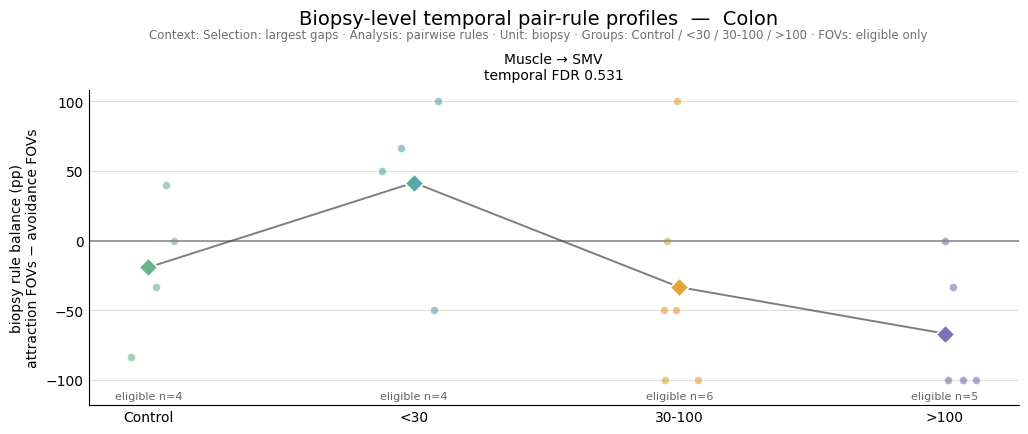

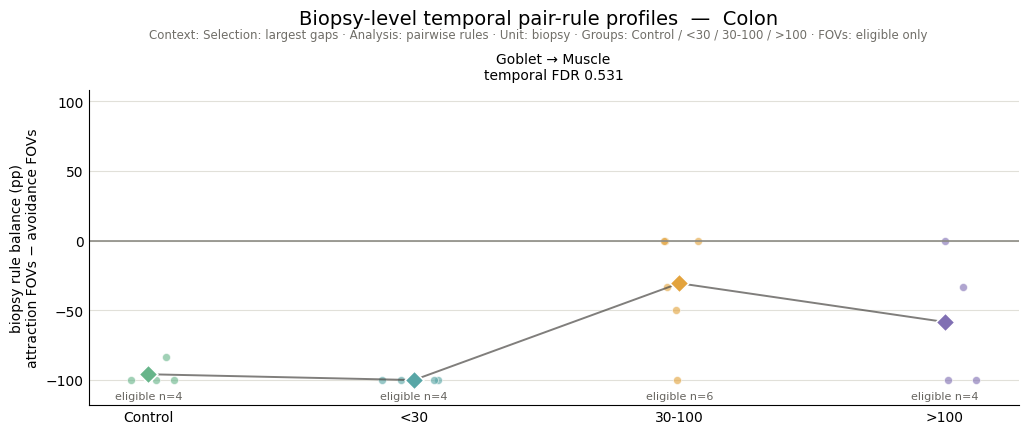

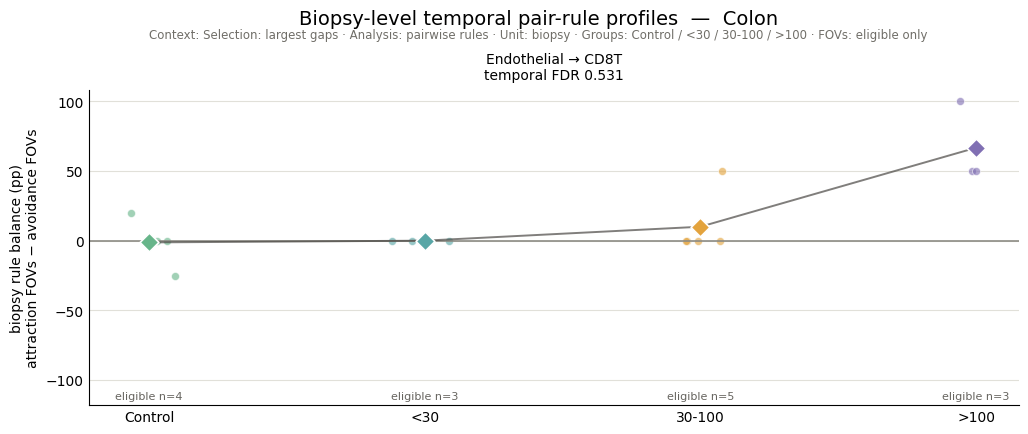

In [15]:
display(result_table(time_results["Colon"]))

dv.plot_temporal_screen(
    time_results["Colon"], scope="Colon", fdr_threshold=FDR_CUTOFF,
)

colon_metadata = biopsy_metadata[biopsy_metadata["Organ"] == "Colon"]
for rule in strongest(time_results["Colon"]):
    dv.plot_time_profiles(
        biopsy_values["Colon"], colon_metadata, [rule],
        time_results["Colon"], DISPLAY_GROUPS, group_col="Time group",
        scope="Colon — Selection: largest gaps",
        save=TEX_TIME_EXPORTS.get(("Colon", rule)),
    )


### Duodenum

,<30 net %,30–100 net %,>100 net %,largest gap (pp),lowest,highest,temporal FDR
Clean_Rule,,,,,,,
Plasma -> Goblet,-39.9,-100.0,-28.7,71.3,30-100,>100,0.367327
Goblet -> Plasma,-55.6,-100.0,-39.8,60.2,30-100,>100,0.868226
Goblet -> Plasma_CD38,-51.9,-77.8,-29.5,48.3,30-100,>100,0.926665
Neuron -> Goblet,-42.1,0.0,-30.6,42.1,<30,30-100,0.926665
Plasma_CD38 -> Fibroblast,4.0,34.7,40.6,36.7,<30,>100,0.926665
Plasma -> Fibroblast,13.9,43.3,23.7,29.4,<30,30-100,0.926665
Plasma -> Muscle,-11.2,-33.3,-4.2,29.2,30-100,>100,0.926665
Fibroblast -> Goblet,-80.0,-100.0,-71.9,28.1,30-100,>100,0.926665
CD8T -> CD4T,0.0,25.0,14.2,25.0,<30,30-100,0.926665


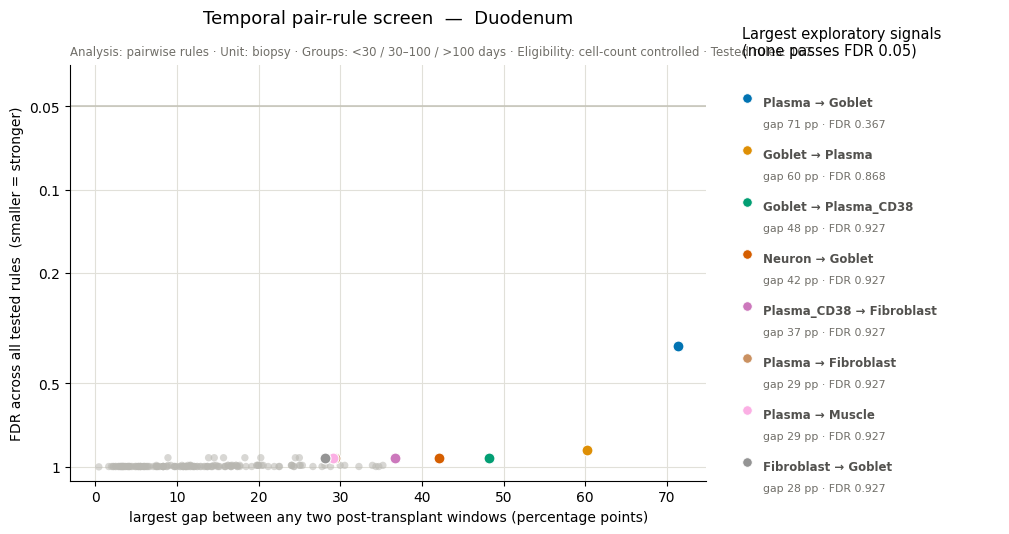

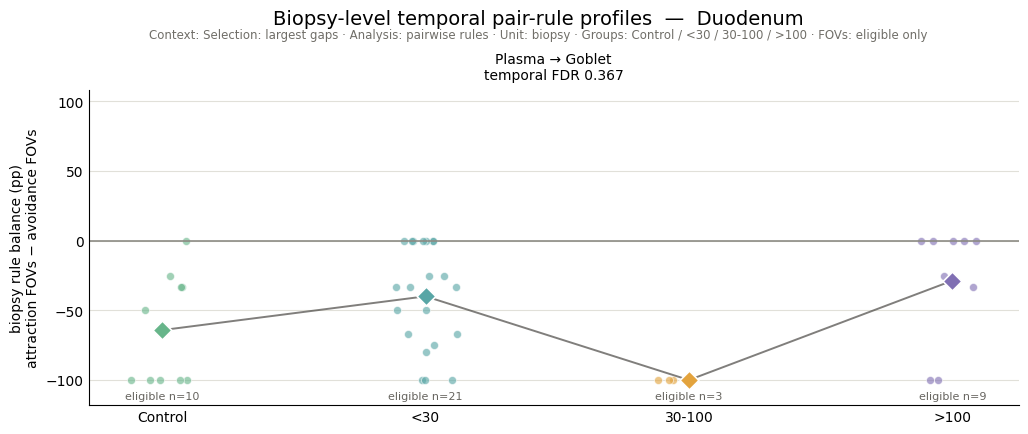

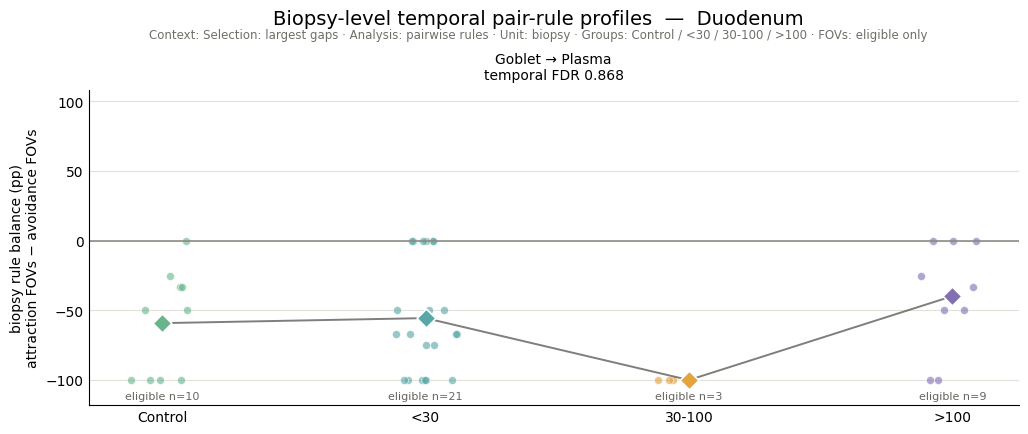

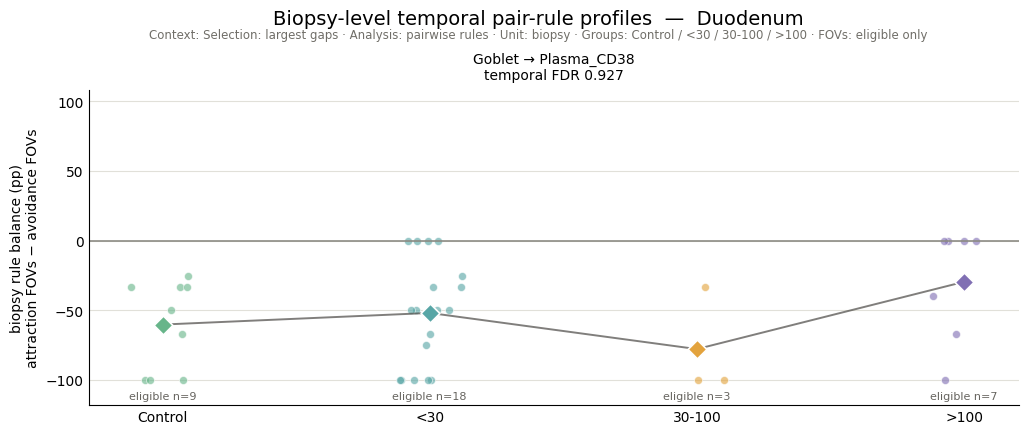

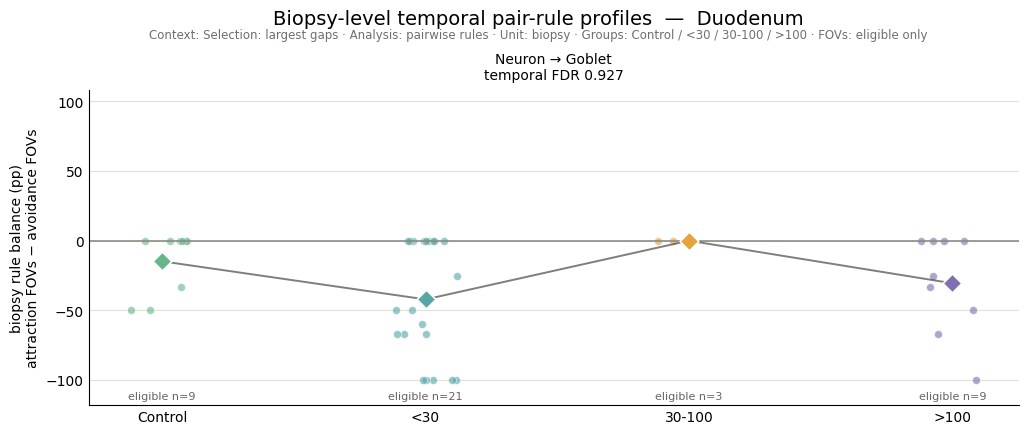

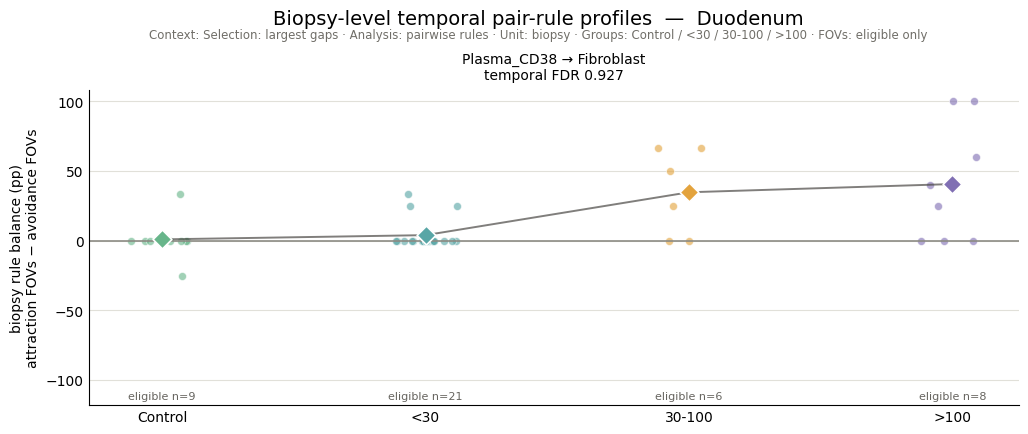

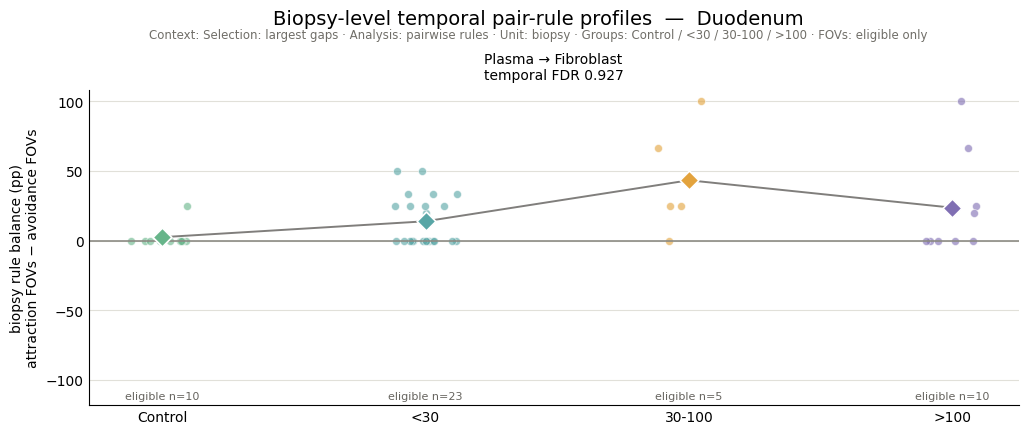

In [16]:
display(result_table(time_results["Duodenum"]))

dv.plot_temporal_screen(
    time_results["Duodenum"], scope="Duodenum", fdr_threshold=FDR_CUTOFF,
)

duodenum_metadata = biopsy_metadata[biopsy_metadata["Organ"] == "Duodenum"]
for rule in strongest(time_results["Duodenum"]):
    dv.plot_time_profiles(
        biopsy_values["Duodenum"], duodenum_metadata, [rule],
        time_results["Duodenum"], DISPLAY_GROUPS, group_col="Time group",
        scope="Duodenum — Selection: largest gaps",
    )


## Pooled time windows

### Colon

,contrast,rule,first group net %,second group net %,gap (pp),n_eligible_a,n_eligible_b,joint FDR
0,<30 + 30–100 days vs >100 days,SMV -> Endothelial,88.9,25.0,63.9,9,4,0.607878
1,<30 + 30–100 days vs >100 days,CD8T -> Goblet,-22.0,-75.0,53.0,13,3,0.607878
2,<30 + 30–100 days vs >100 days,Endothelial -> CD8T,6.2,66.7,-60.4,8,3,0.624449
3,<30 + 30–100 days vs >100 days,Fibroblast -> Muscle,-15.0,-55.0,40.0,10,5,0.693995
4,<30 + 30–100 days vs >100 days,Macrophage -> CD4T,28.6,0.0,28.6,11,4,0.693995
5,<30 + 30–100 days vs >100 days,CD8T -> Epithelial,0.6,-25.0,25.6,13,4,0.693995
6,<30 + 30–100 days vs >100 days,CD4T -> Goblet,-39.4,0.0,-39.4,11,3,0.742751
7,<30 + 30–100 days vs >100 days,SMV -> Goblet,-37.4,-68.3,31.0,13,5,0.742751
8,<30 days vs 30–100 + >100 days,SMV -> Goblet,-15.0,-57.9,42.9,5,13,0.624449
9,<30 days vs 30–100 + >100 days,Muscle -> SMV,41.7,-48.5,90.2,4,11,0.693995


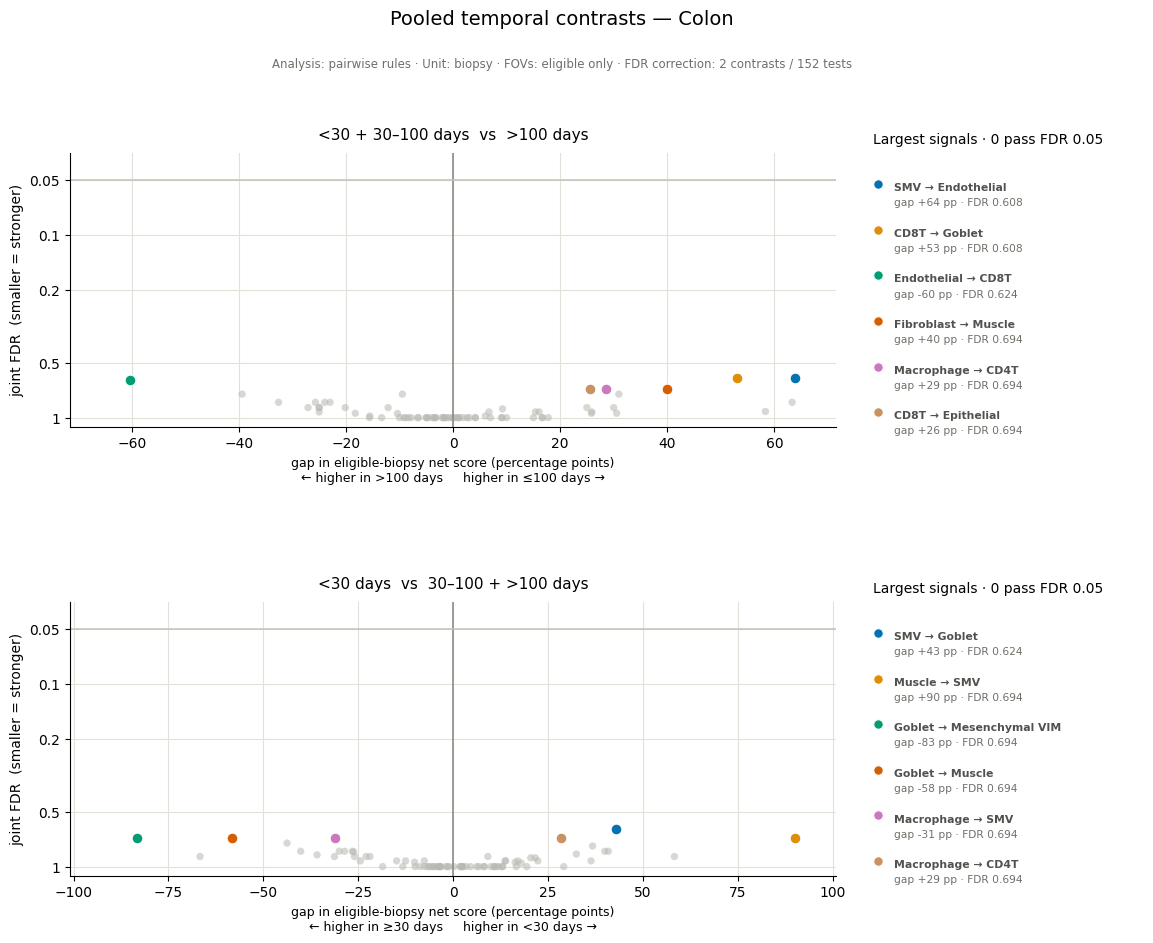

In [17]:
display(pooled_table(pooled_results["Colon"]))

dv.plot_pooled_time_contrasts(
    pooled_results["Colon"], POOLED_CONTRASTS, organ="Colon",
    fdr_threshold=FDR_CUTOFF,
)


### Duodenum

,contrast,rule,first group net %,second group net %,gap (pp),n_eligible_a,n_eligible_b,joint FDR
0,<30 + 30–100 days vs >100 days,Plasma_CD38 -> Fibroblast,10.8,40.6,-29.8,27,8,0.430914
1,<30 + 30–100 days vs >100 days,CD8T -> Goblet,-0.7,-56.5,55.8,12,9,0.517097
2,<30 + 30–100 days vs >100 days,Goblet -> CD8T,-39.6,-85.2,45.6,12,9,0.915692
3,<30 + 30–100 days vs >100 days,Fibroblast -> Mesenchymal_VIM,1.4,14.6,-13.1,23,8,0.915692
4,<30 + 30–100 days vs >100 days,Fibroblast -> Macrophage_Calp,-40.0,0.0,-40.0,5,3,1.000000
5,<30 + 30–100 days vs >100 days,Goblet -> Monocyte,-70.0,-33.3,-36.7,5,3,1.000000
6,<30 + 30–100 days vs >100 days,SMV -> Endocrine,-56.1,-20.0,-36.1,11,5,1.000000
7,<30 + 30–100 days vs >100 days,BrunnerGland -> Neuron,-50.0,-16.7,-33.3,11,3,1.000000
8,<30 days vs 30–100 + >100 days,Plasma_CD38 -> Fibroblast,4.0,38.1,-34.1,21,14,0.086183
9,<30 days vs 30–100 + >100 days,Goblet -> CD8T,-32.5,-83.3,50.8,10,11,0.258548


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_duodenum_pooled.pdf


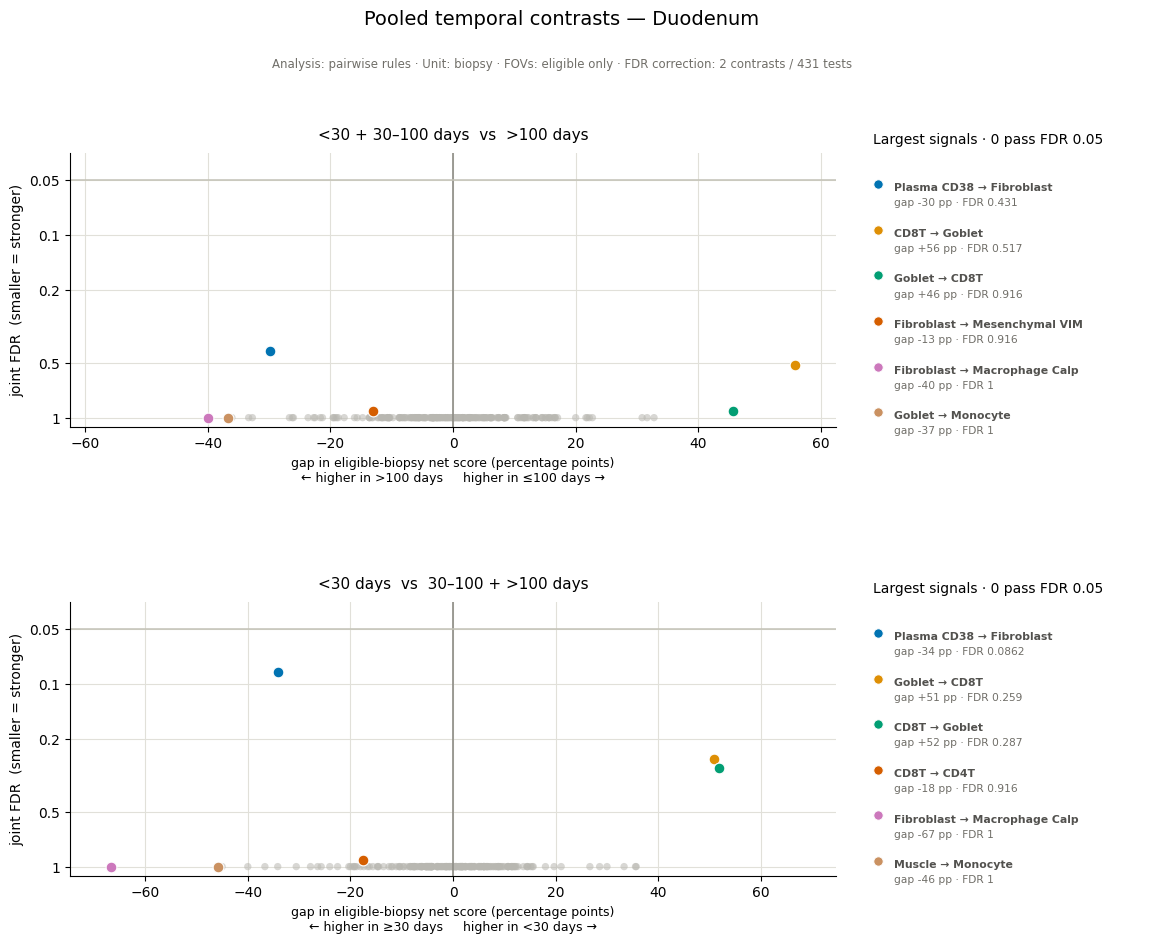

In [18]:
display(pooled_table(pooled_results["Duodenum"]))

dv.plot_pooled_time_contrasts(
    pooled_results["Duodenum"], POOLED_CONTRASTS, organ="Duodenum",
    fdr_threshold=FDR_CUTOFF, save="tex_new_time_duodenum_pooled.pdf",
)


## Representative FOVs

### Colon

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_cd8_goblet_fovs.pdf


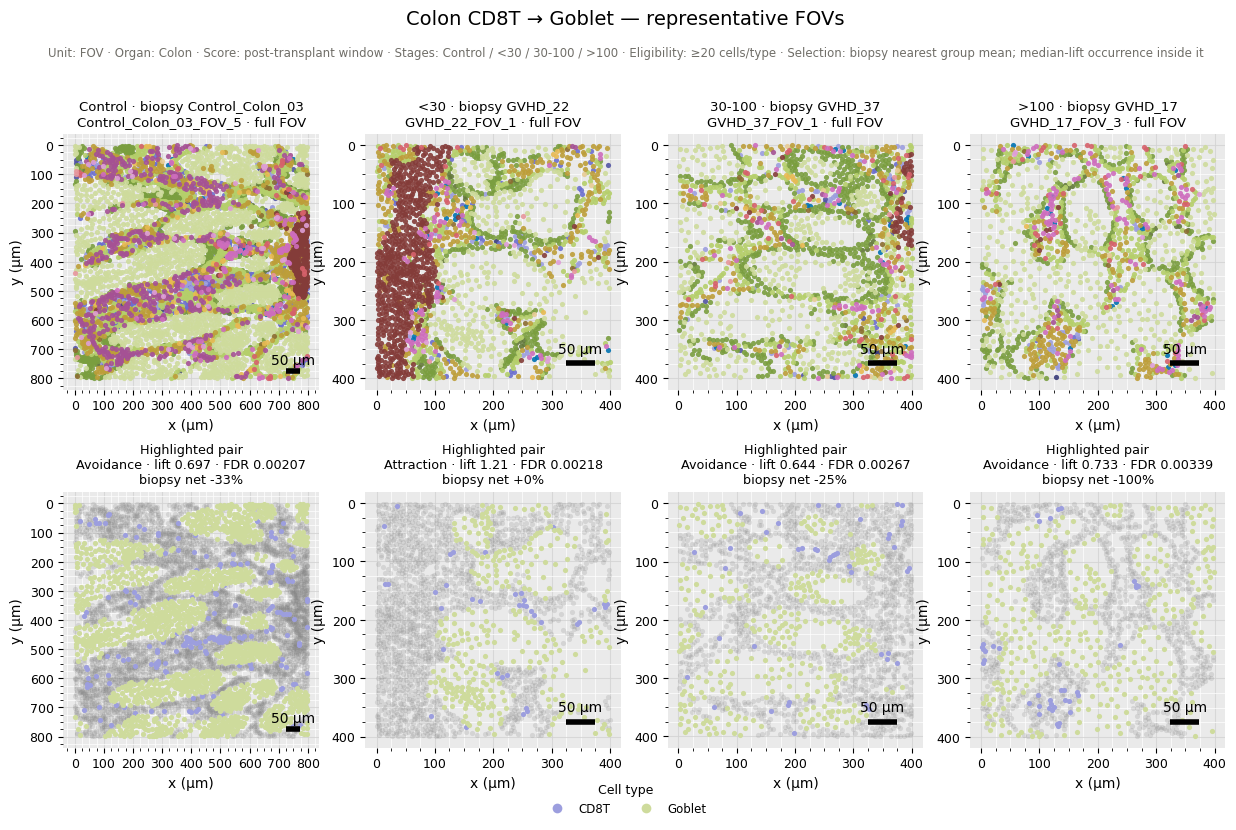

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_smv_endothelial_fovs.pdf


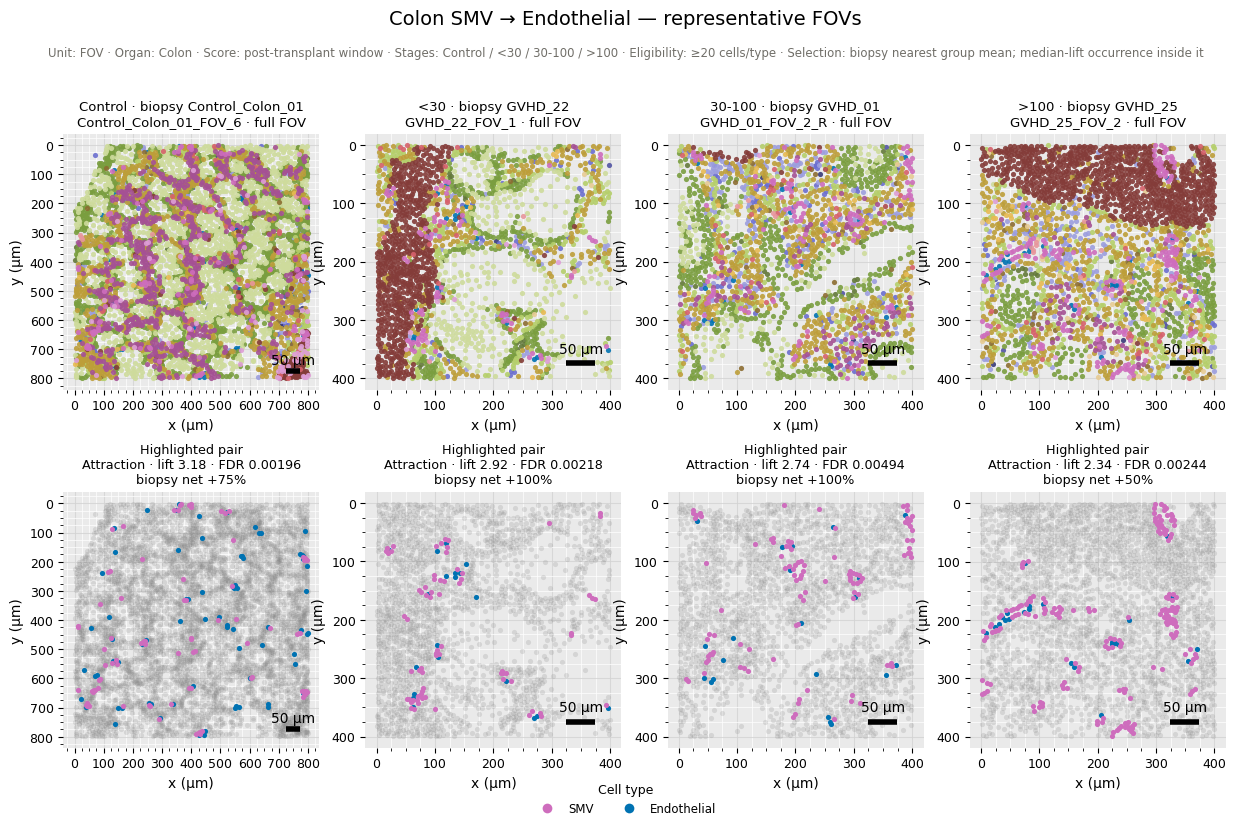

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_colon_smv_goblet_fovs.pdf


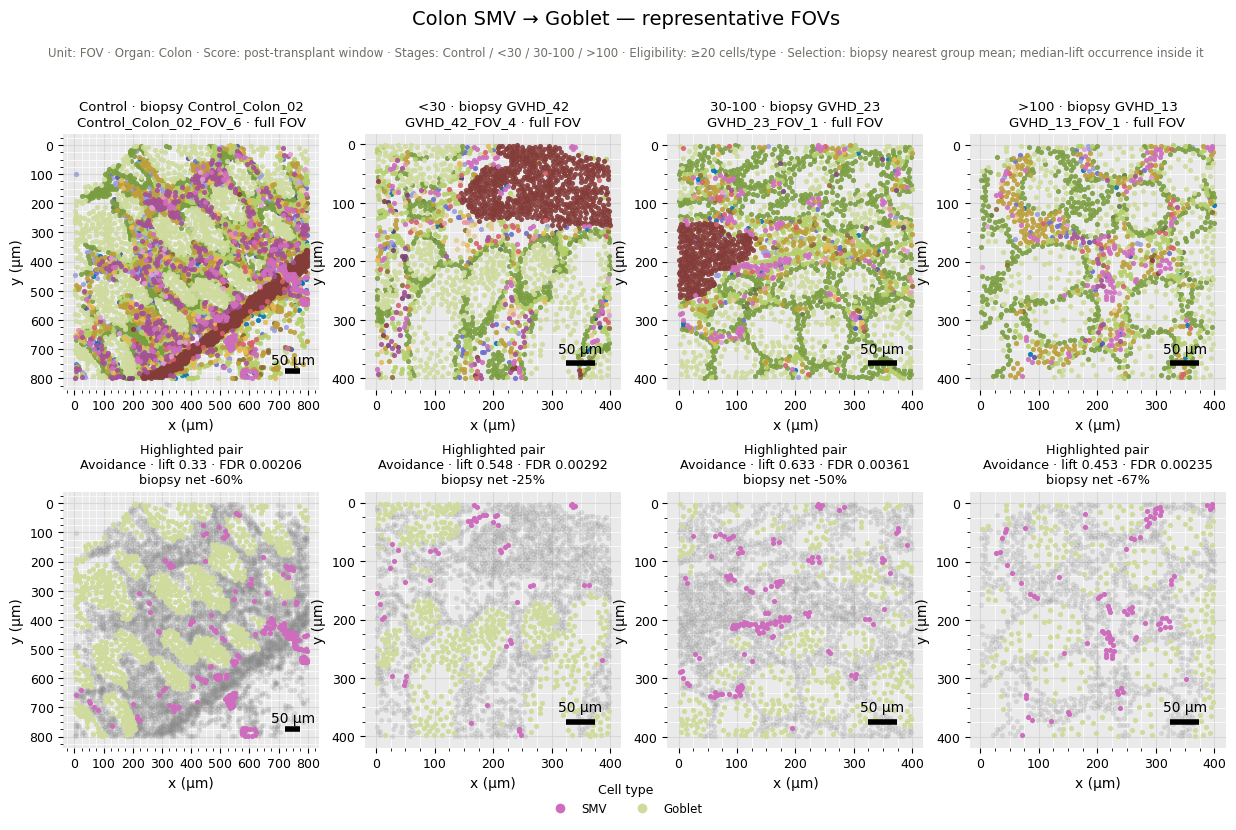

In [19]:
show_time_fovs("Colon")

### Duodenum

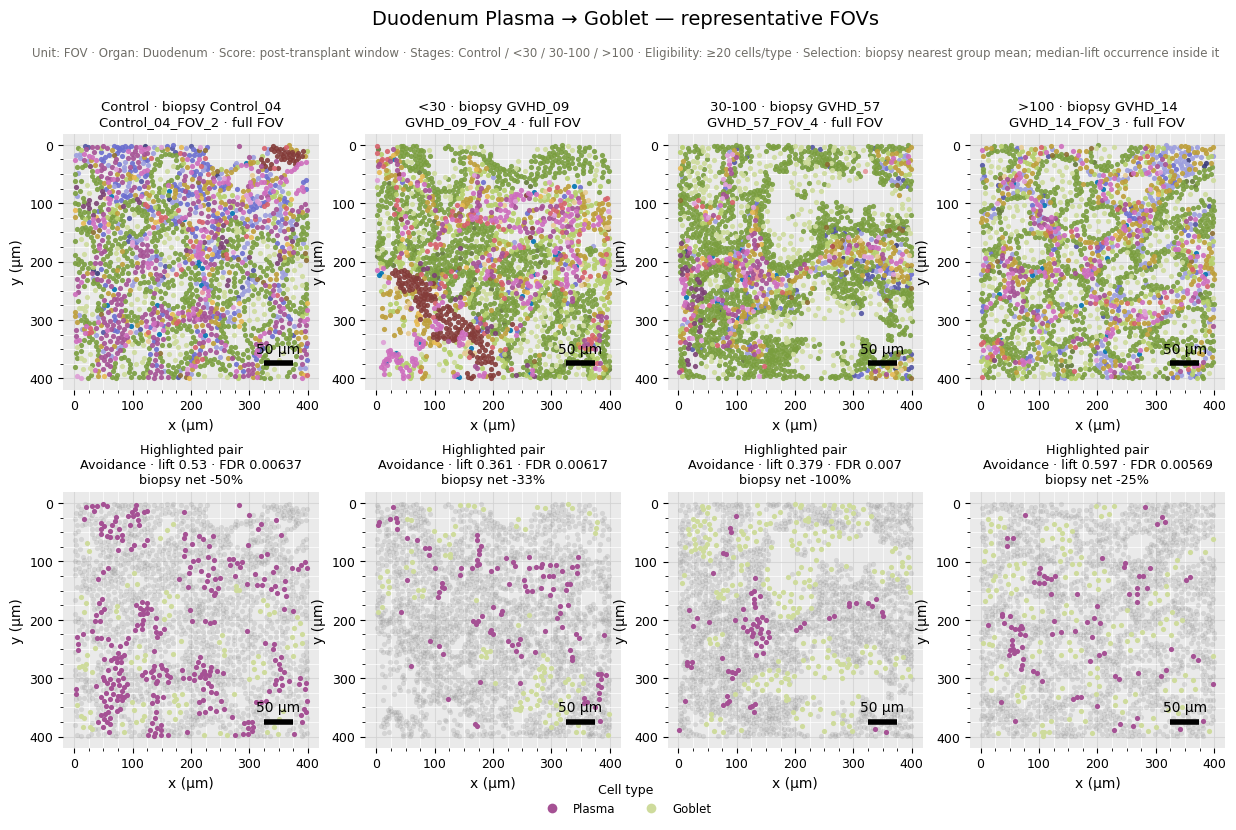

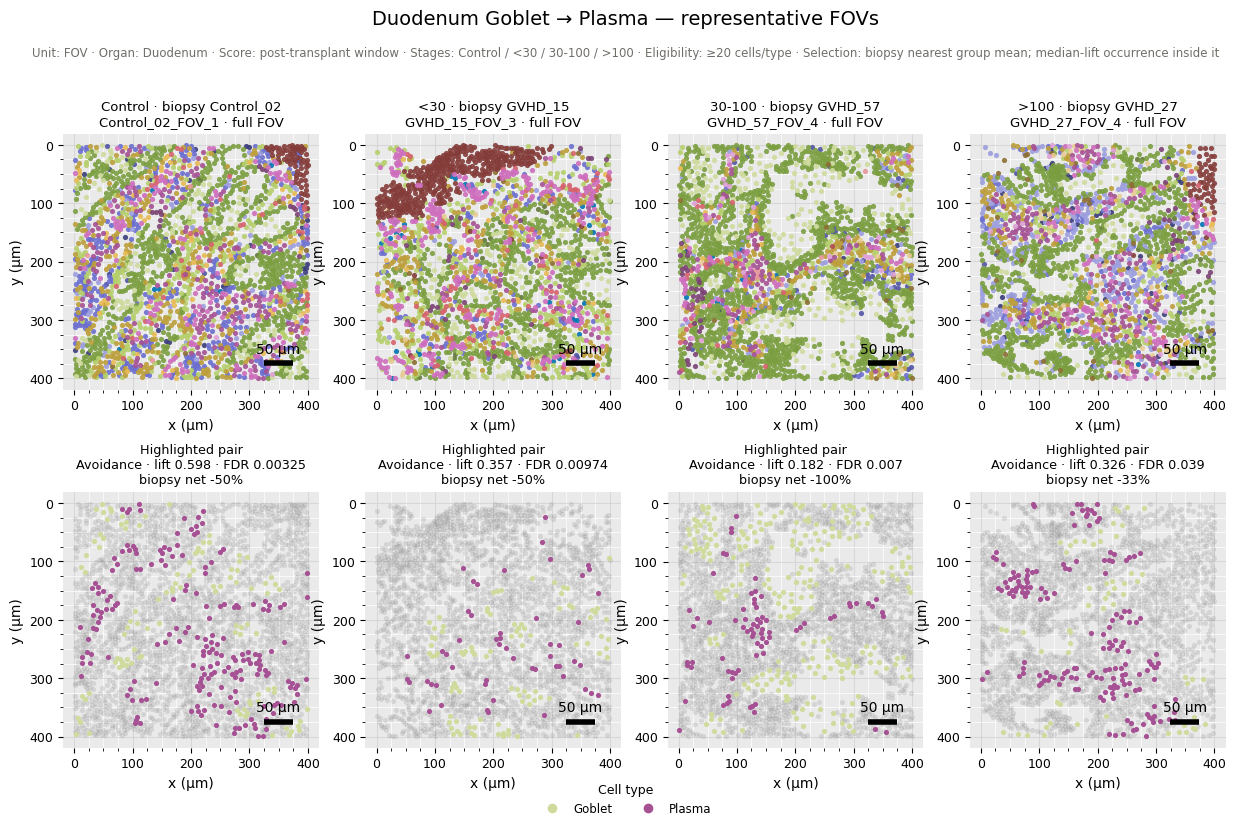

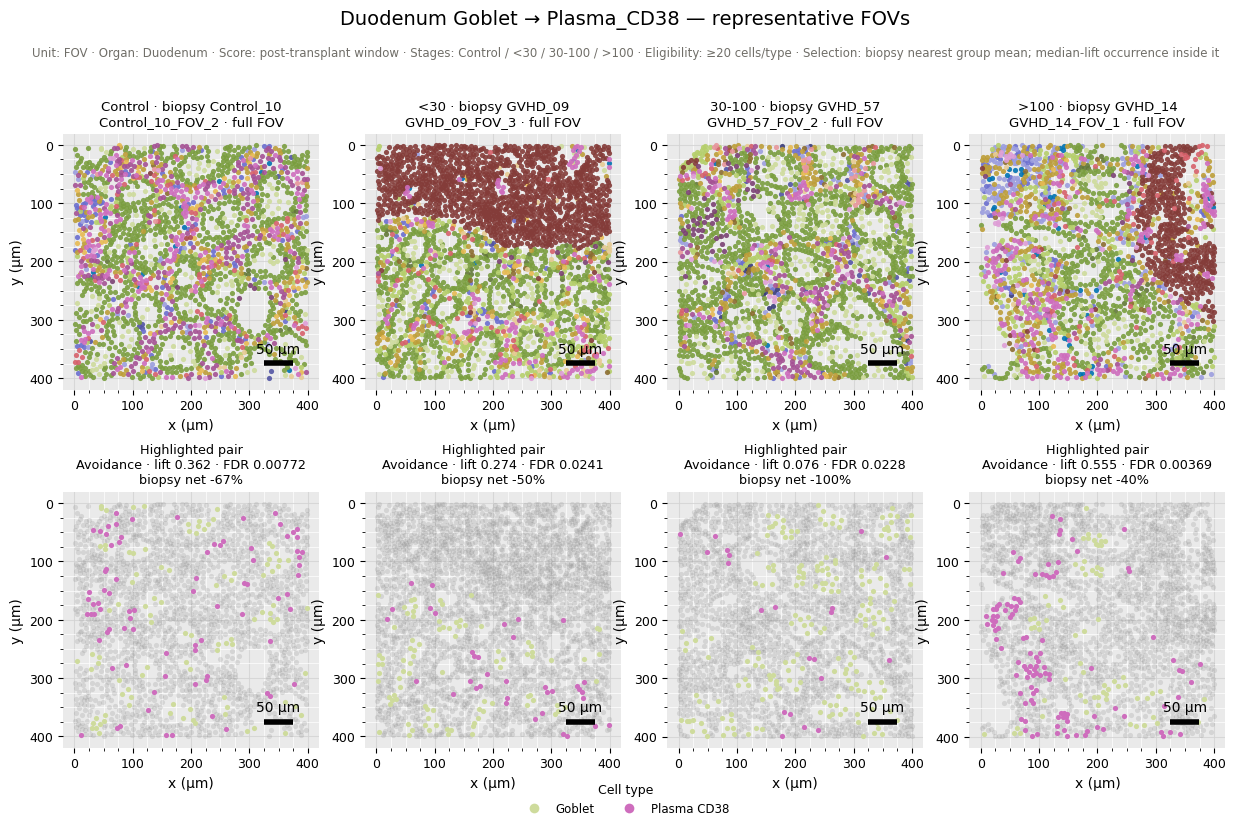

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_new_time_duodenum_plasma_cd38_fibroblast_fovs.pdf


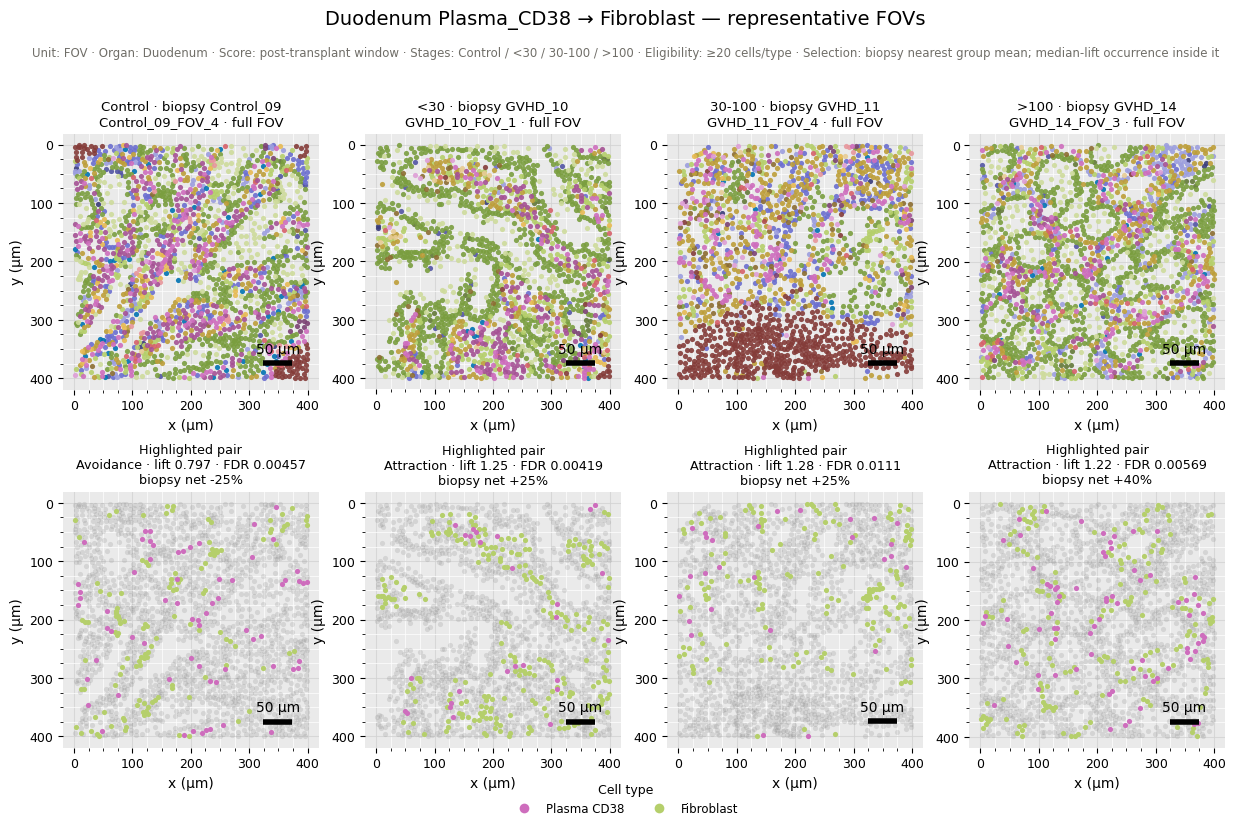

In [20]:
show_time_fovs("Duodenum")

## Paper-linked immune rules

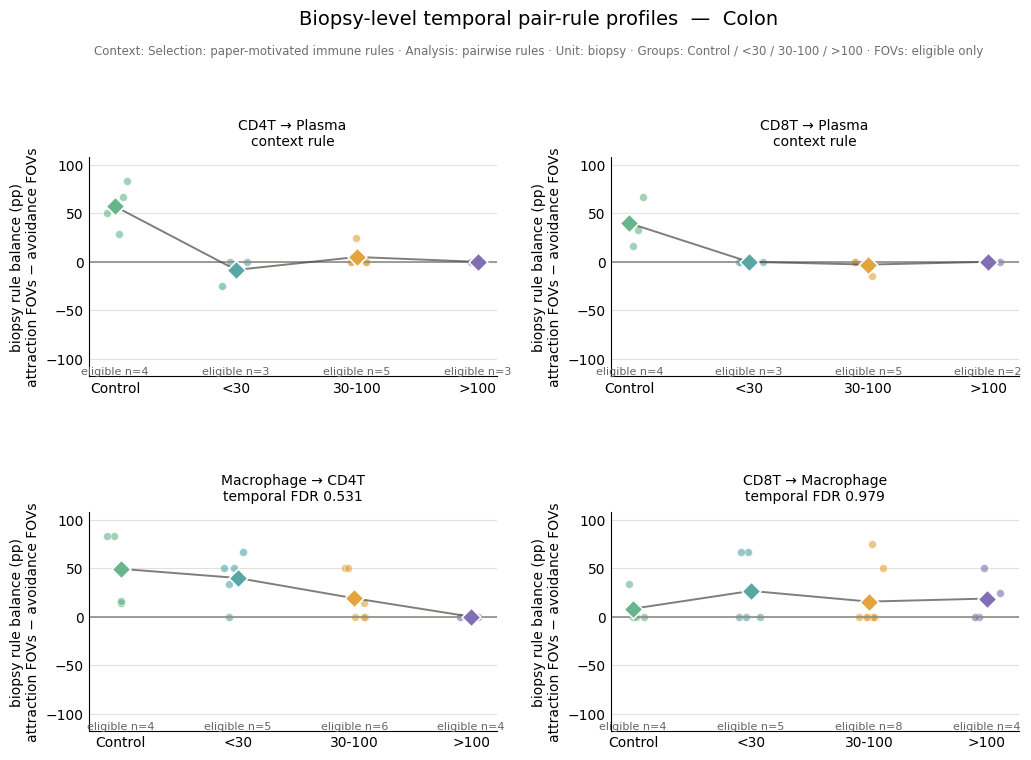

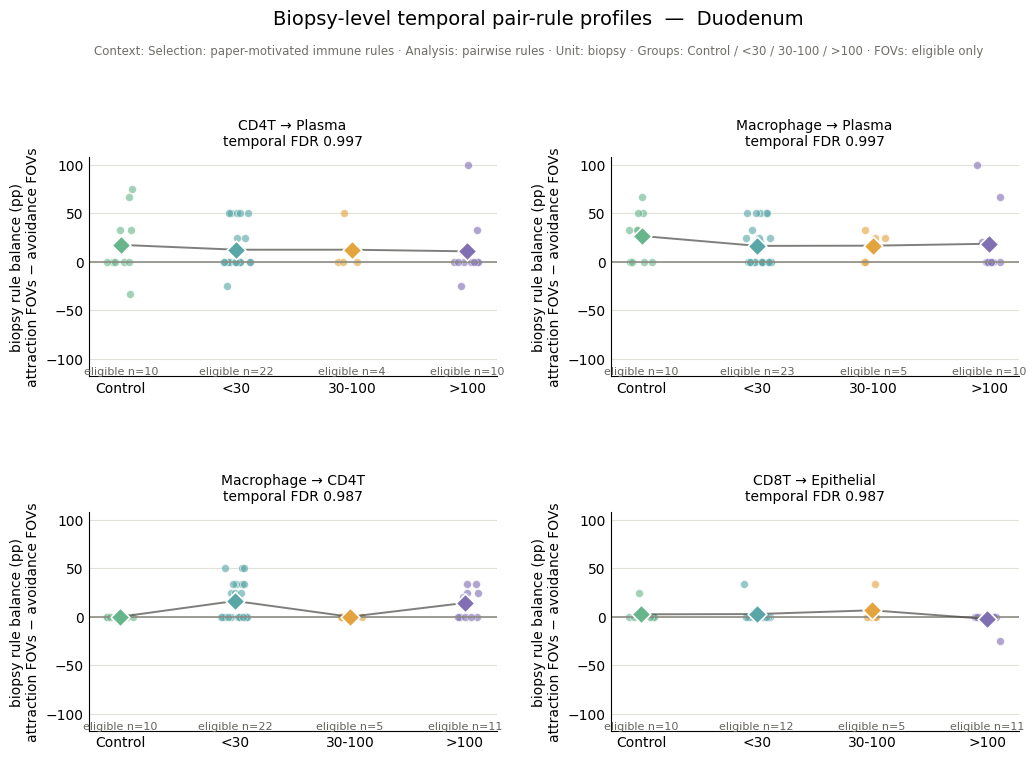

In [21]:
requested = {
    "Colon": [
        "CD4T -> Plasma", "CD8T -> Plasma",
        "Macrophage -> CD4T", "CD8T -> Macrophage",
    ],
    "Duodenum": [
        "CD4T -> Plasma", "Macrophage -> Plasma",
        "Macrophage -> CD4T", "CD8T -> Epithelial",
    ],
}

for number, organ in enumerate(ORGANS, start=8):
    metadata = biopsy_metadata[biopsy_metadata["Organ"] == organ]
    available = [rule for rule in requested[organ] if rule in biopsy_values[organ].index]
    dv.plot_time_profiles(
        biopsy_values[organ], metadata, available, time_results[organ],
        DISPLAY_GROUPS, group_col="Time group",
        scope=f"{organ} — Selection: paper-motivated immune rules",
    )
